# Graph AML Detector: Exploratory Data Analysis (EDA)

**Date:** 2026-06-06  
**Author:** Luis Renteria Lezano  
[LinkedIn](https://www.linkedin.com/in/renteria-luis) | [GitHub](https://github.com/renteria-luis)

## Executive Summary
- **Goal:** Test whether graph structure adds signal for detecting illicit Bitcoin transactions, by comparing a GraphSAGE GNN against an XGBoost tabular baseline on the same features.
- **Source:** The Elliptic Data Set (Weber et al., 2019), loaded via PyTorch Geometric's `EllipticBitcoinDataset`.
- **Data:** ~204K transactions as nodes, ~234K directed fund-flow edges, 165 anonymized features plus a time step (1 to 49); labels are ~2% illicit, ~21% licit, the rest unlabeled.

## 0. Reproducibility & Environment Setup

In [18]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

from torch_geometric.datasets import EllipticBitcoinDataset

import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

# Paths
DATA = Path('../data')
DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')

## 1. Introduction

The Elliptic Data Set is a graph of real Bitcoin transactions released by Elliptic with the MIT-IBM Watson AI Lab (Weber et al., 2019). Each node is a transaction and each directed edge is a flow of funds from one transaction to the next. The task is to classify each transaction as licit or illicit.

There are three Elliptic datasets, solving different problems:

- Elliptic (2019), used here: ~204K transactions, node-level licit/illicit classification.
- Elliptic++: extends the original with actor and wallet nodes, making it a heterogeneous graph.
- Elliptic2 (2024): a much larger graph (~49M nodes, ~196M edges) for subgraph classification, detecting the shapes of laundering rather than single transactions.

This project uses the original. Its task, flagging an individual transaction, matches the detect-then-investigate design; its scale fits a single 6 GB GPU with neighbor sampling; and it loads directly through PyTorch Geometric. Elliptic++ would pull in heterogeneous GNNs and Elliptic2 a different, subgraph-level task, both beyond scope here.

## 2. Data Load & Overview

In [11]:
# First run downloads the three CSVs into data/raw/ and builds a processed
# data.pt in data/processed/. root='data' matches the repo layout, and data/
# is already gitignored.
dataset = EllipticBitcoinDataset(root=DATA)
data = dataset[0]
print(data)
print('features:', data.num_features)

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])
features: 165


In [12]:
# The features file has no header: column 0 is txId, column 1 is the time
# step (1 to 49), and the rest are the anonymized features.
features = pd.read_csv(f'{DATA_RAW}/elliptic_txs_features.csv', header=None)
print('Raw features shape:', features.shape)
features.columns = ['txId', 'time_step'] + [f'feat_{i}' for i in range(1, features.shape[1] - 1)]

# classes and edgelist do have headers
classes = pd.read_csv(f'{DATA_RAW}/elliptic_txs_classes.csv')   # txId, class
edges = pd.read_csv(f'{DATA_RAW}/elliptic_txs_edgelist.csv')    # txId1, txId2

print('classes:', classes.shape)
print('edges:', edges.shape)
print('raw class values:', classes['class'].unique())

raw features shape: (203769, 167)
classes: (203769, 2)
edges: (234355, 2)
raw class values: <ArrowStringArray>
['unknown', '2', '1']
Length: 3, dtype: str


In [13]:
# In the raw files, '1' is illicit, '2' is licit, 'unknown' is unlabeled.
# astype(str) guards against the column being read as ints.
label_names = {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
classes['label'] = classes['class'].astype(str).map(label_names)

counts = classes['label'].value_counts()
total = len(classes)
print(counts)
print((counts / total * 100).round(2))

labeled = counts['illicit'] + counts['licit']
print('illicit share of labeled:', round(counts['illicit'] / labeled * 100, 2), '%')

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64
label
unknown    77.15
licit      20.62
illicit     2.23
Name: count, dtype: float64
illicit share of labeled: 9.76 %


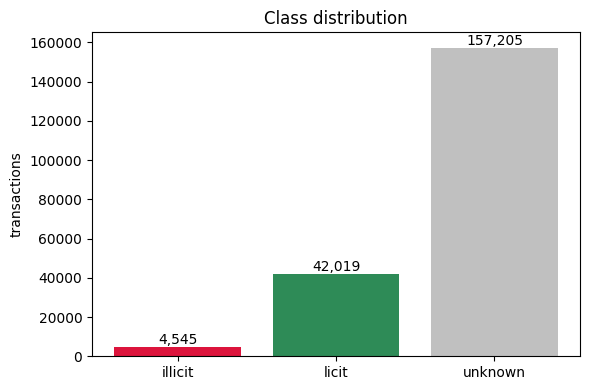

In [21]:
order = ['illicit', 'licit', 'unknown']
colors = ['crimson', 'seagreen', 'silver']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(order, [counts[k] for k in order], color=colors)
ax.set_ylabel('transactions')
ax.set_title('Class distribution')
for i, k in enumerate(order):
    ax.text(i, counts[k], f'{counts[k]:,}', ha='center', va='bottom')
fig.tight_layout()